In [1]:
# ============================================================
# Quantum Mechanics Fundamentals DEMO
# Double-Slit + Stern–Gerlach [Unified in Hilbert Space]
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 12

print("Notebook initialized.")

Notebook initialized.


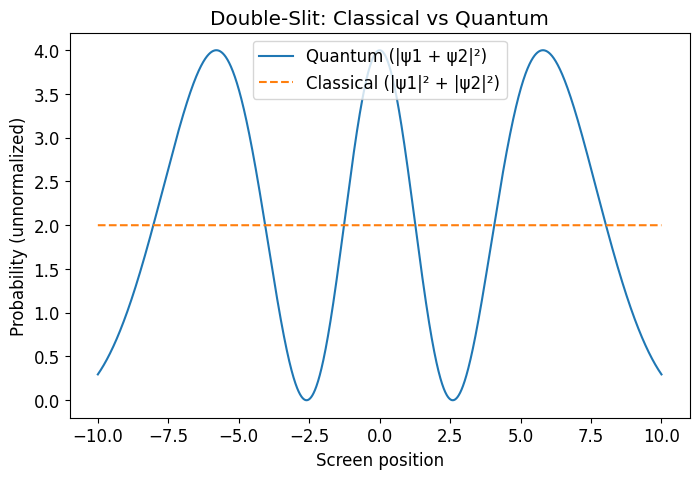

In [2]:
# ------------------------------------------------------------
# DOUBLE-SLIT: AMPLITUDE ADDITION
# ------------------------------------------------------------

# Screen coordinate
x = np.linspace(-10, 10, 2000)

# Physical parameters
wavelength = 1.0
k = 2 * np.pi / wavelength
d = 2.0              # slit separation
L = 10              # distance to screen

# Complex amplitudes from two slits
psi1 = np.exp(1j * k * np.sqrt((x - d/2)**2 + L**2))
psi2 = np.exp(1j * k * np.sqrt((x + d/2)**2 + L**2))

# Quantum interference
P_quantum = np.abs(psi1 + psi2)**2

# Classical probability addition
P_classical = np.abs(psi1)**2 + np.abs(psi2)**2

plt.plot(x, P_quantum, label="Quantum (|ψ1 + ψ2|²)")
plt.plot(x, P_classical, '--', label="Classical (|ψ1|² + |ψ2|²)")
plt.xlabel("Screen position")
plt.ylabel("Probability (unnormalized)")
plt.title("Double-Slit: Classical vs Quantum")
plt.legend()
plt.show()

In [ ]:
# ------------------------------------------------------------
# EXPLICIT INTERFERENCE TERM
# ------------------------------------------------------------

cross_term = 2 * np.real(np.conj(psi1) * psi2)

plt.plot(x, cross_term)
plt.title("Interference Cross Term: 2 Re(ψ1* ψ2)")
plt.xlabel("Screen position")
plt.ylabel("Cross-term contribution")
plt.show()

print("Notice: Interference comes entirely from the cross term.")


In [ ]:
# ------------------------------------------------------------
# Decoherence (Which-Path Information)
# DECOHERENCE PARAMETER γ
# γ = 1 → full coherence
# γ = 0 → full which-path information
# ------------------------------------------------------------

gamma = 0   # Change between 1 and 0

P_decoherence = (
    np.abs(psi1)**2 +
    np.abs(psi2)**2 +
    gamma * 2*np.real(np.conj(psi1)*psi2)
)

plt.plot(x, P_decoherence)
plt.title(f"Decoherence with γ = {gamma}")
plt.xlabel("Screen position")
plt.ylabel("Probability")
plt.show()

print("γ reduces the interference term.")

In [ ]:
# ============================================================
# STERN–GERLACH IN 2D HILBERT SPACE
# ============================================================

# Define Z basis
up_z = np.array([1, 0], dtype=complex)
down_z = np.array([0, 1], dtype=complex)

# Define X basis
up_x = (1/np.sqrt(2)) * np.array([1, 1], dtype=complex)
down_x = (1/np.sqrt(2)) * np.array([1, -1], dtype=complex)

def probability(state, outcome):
    return np.abs(np.vdot(outcome, state))**2

print("Hilbert space initialized.")
print (down_z)
# print (down_x)

In [ ]:
# ------------------------------------------------------------
# First Stern–Gerlach Measurement (P=∣⟨ϕ∣ψ⟩∣2)
# MEASURE |+z> IN X BASIS
# ------------------------------------------------------------

print("P(+x | +z) =", probability(down_z, up_x))
print("P(-x | +z) =", probability(down_z, down_x))

In [ ]:
  # ------------------------------------------------------------
# Measurement Collapse & Re-Measurement
# COLLAPSE TO |+x> THEN MEASURE Z
# ------------------------------------------------------------

collapsed_state = up_x

print("P(+z | +x) =", probability(collapsed_state, up_z))
print("P(-z | +x) =", probability(collapsed_state, down_z))

# Where did the original |+z⟩ information go? Measurement changed the state.

In [ ]:
# ------------------------------------------------------------
# Pauli Matrices & Non-Commutation
# NON-COMMUTING OBSERVABLES
# ------------------------------------------------------------

sigma_x = np.array([[0, 1],
                    [1, 0]], dtype=complex)

sigma_z = np.array([[1, 0],
                    [0, -1]], dtype=complex)

commutator = sigma_x @ sigma_z - sigma_z @ sigma_x

print("Commutator [σx, σz] =")
print(commutator)

In [ ]:
# ------------------------------------------------------------
# Unification (Density Matrix View)
# DENSITY MATRIX & DECOHERENCE
# ------------------------------------------------------------

# Pure superposition state
psi = (1/np.sqrt(2)) * np.array([1, 1], dtype=complex)

# Density matrix
rho = np.outer(psi, np.conj(psi))

print("Pure state density matrix:")
print(rho)

# Decohered version (remove off-diagonal terms)
rho_deco = np.array([[rho[0,0], 0],
                     [0, rho[1,1]]], dtype=complex)

print("\nDecohered density matrix:")
print(rho_deco)

# Off-diagonal terms = coherence
# Remove them → no interference
# Same physics as double-slit γ = 0

In [ ]:
# ============================================================
# NUMERICAL MCQs — DOUBLE SLIT (MCQ 1)
# ============================================================

print("MCQ 1")
print("If ψ1 = 1 and ψ2 = -1, what is P = |ψ1 + ψ2|^2 ?")
print("A) 0   B) 1   C) 2   D) 4")

In [ ]:
# ============================================================
# NUMERICAL MCQs — DOUBLE SLIT (MCQ 2)
# ============================================================

print("\nMCQ 2")
print("If ψ1 = 1 and ψ2 = i, what is P = |ψ1 + ψ2|^2 ?")
print("A) 0   B) 1   C) 2   D) 4")

In [ ]:
# ============================================================
# NUMERICAL MCQs — DOUBLE SLIT (MCQ 3)
# ============================================================

print("\nMCQ 3")
print("If ψ1 = 1 and ψ2 = e^{iπ/3}, what is P = |ψ1 + ψ2|^2 ?")
print("A) 1   B) 2   C) 3   D) 4")

In [ ]:
# ============================================================
# NUMERICAL MCQs — DOUBLE SLIT (MCQ 4)
# ============================================================

print("\nMCQ 4 (Decoherence)")
print("If |ψ1|^2 = |ψ2|^2 = 1 and γ = 0, what is P?")
print("A) 0   B) 1   C) 2   D) 4")

In [ ]:
# ============================================================
# MCQ 5
# ============================================================

print("MCQ 5")
print("What is P(+x | +z)?")
print("A) 0   B) 1/4   C) 1/2   D) 1")

In [ ]:
print("\nMCQ 6")
print("Start in |+z>. Measure X. Get +x. Then measure Z.")
print("What is P(+z)?")
print("A) 0   B) 1/4   C) 1/2   D) 1")

In [ ]:
print("\nMCQ 7")
print("What is P(+z | +z)?")
print("A) 0   B) 1/2   C) 1   D) 2")

In [ ]:
print("\nMCQ 8")
print("What is P(-z | +x)?")
print("A) 0   B) 1/2   C) 1   D) 1/4")